<a href="https://colab.research.google.com/github/Aymenchaghoub/TP-MAL/blob/main/Copy_of_%5B02%5D_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# La régression linéaire : solution en forme close et descente de gradient

## Données
On commence par générer des données. Les données en entrée seront dans $\mathbb{R}$, et pour chaque point $x_i \in \mathbb{R}$, il faudra prédire un $y_i \in \mathbb{R}$.

In [ ]:
import numpy as np
nb_points = 30
true_w = -.8
true_b = .5
data_x = np.random.rand(nb_points, 1)
data_y = data_x * true_w + true_b + np.random.randn(nb_points, 1) * .1

In [ ]:
print('données en entrée\n', data_x)
print('données à prédire\n', data_y)

données en entrée
 [[0.54323603]
 [0.46494943]
 [0.10288521]
 [0.8561042 ]
 [0.18178619]
 [0.03851239]
 [0.99318197]
 [0.63005974]
 [0.06277221]
 [0.44914245]
 [0.95471752]
 [0.25516857]
 [0.32853551]
 [0.62694571]
 [0.22299526]
 [0.17297501]
 [0.71191668]
 [0.20630149]
 [0.24585337]
 [0.20089622]
 [0.6642195 ]
 [0.34249155]
 [0.09319907]
 [0.9774172 ]
 [0.53561088]
 [0.1825408 ]
 [0.76856818]
 [0.21663107]
 [0.77733132]
 [0.89400882]]
données à prédire
 [[ 1.01197105e-01]
 [ 2.10350781e-01]
 [ 3.36040925e-01]
 [-2.39823356e-01]
 [ 2.39349001e-01]
 [ 2.93377437e-01]
 [-2.39675752e-01]
 [-8.21456039e-05]
 [ 4.17035570e-01]
 [ 5.49197304e-02]
 [-1.96183207e-01]
 [ 2.49878906e-01]
 [ 2.19221553e-01]
 [ 3.25034469e-02]
 [ 4.85395684e-01]
 [ 1.80622439e-01]
 [ 6.80298263e-02]
 [ 3.27958492e-01]
 [ 2.61818548e-01]
 [ 1.78402191e-01]
 [ 4.91715961e-02]
 [ 1.53522214e-01]
 [ 4.92891593e-01]
 [-2.84228179e-01]
 [ 1.16759553e-01]
 [ 3.46559542e-01]
 [-1.70850450e-01]
 [ 3.10537003e-01]
 [-1.3737

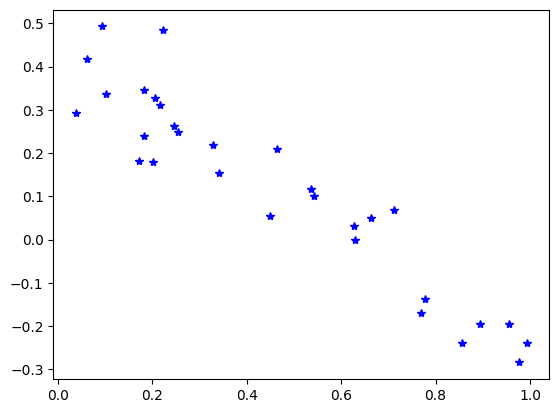

In [ ]:
import matplotlib.pyplot as plt
plt.plot(data_x, data_y, '*b')
plt.show()

In [ ]:
w = np.random.randn()
b = np.random.randn()

## Visualisation du modèle

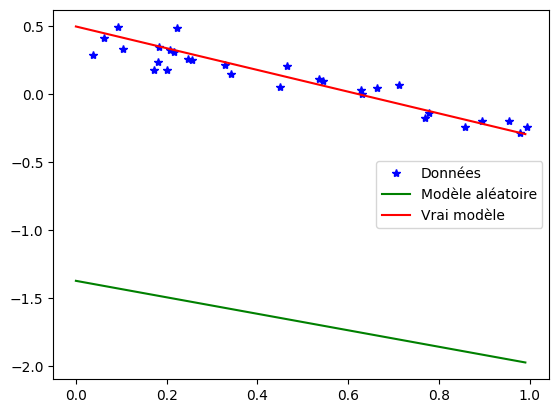

In [ ]:
plt.plot(data_x, data_y, '*b')
o = np.arange(0, 1, .01)
a = w * o + b
plt.plot(o, a, '-g')
true_a = true_w * o + true_b
plt.plot(o, true_a, '-r')
plt.legend(['Données', 'Modèle aléatoire', 'Vrai modèle'])
plt.show()

# Exercices

## 1
Calculer l'Erreur Quadratique Moyenne (EQM) du modèle $\frac{1}{K}∑_{i=0}^{K-1} (\hat{y_i} - y_i)^2$ où $\hat{y_i} = w x_i + b$

In [ ]:
y_hat = w * data_x + b
eqm = np.mean((y_hat - data_y)**2)
print(f"EQM du modèle aléatoire: {eqm:.4f}")

EQM du modèle aléatoire: 3.1421


## 2
Trouver `w_opt` et `b_opt` qui minimisent l'EQM. S'assurer que l'EQM de ce modèle est inférieure à l'EQM du modèle aléatoire calculé en 1, et vérifier que le gradient de l'EQM est nul en `(w_opt, b_opt)`



In [ ]:
data_x

array([[0.54323603],
       [0.46494943],
       [0.10288521],
       [0.8561042 ],
       [0.18178619],
       [0.03851239],
       [0.99318197],
       [0.63005974],
       [0.06277221],
       [0.44914245],
       [0.95471752],
       [0.25516857],
       [0.32853551],
       [0.62694571],
       [0.22299526],
       [0.17297501],
       [0.71191668],
       [0.20630149],
       [0.24585337],
       [0.20089622],
       [0.6642195 ],
       [0.34249155],
       [0.09319907],
       [0.9774172 ],
       [0.53561088],
       [0.1825408 ],
       [0.76856818],
       [0.21663107],
       [0.77733132],
       [0.89400882]])

In [ ]:
Z = np.ones((nb_points, 2))
for i in range(nb_points):
  Z[i, 1] = data_x[i, 0]
print(Z)

[[1.         0.54323603]
 [1.         0.46494943]
 [1.         0.10288521]
 [1.         0.8561042 ]
 [1.         0.18178619]
 [1.         0.03851239]
 [1.         0.99318197]
 [1.         0.63005974]
 [1.         0.06277221]
 [1.         0.44914245]
 [1.         0.95471752]
 [1.         0.25516857]
 [1.         0.32853551]
 [1.         0.62694571]
 [1.         0.22299526]
 [1.         0.17297501]
 [1.         0.71191668]
 [1.         0.20630149]
 [1.         0.24585337]
 [1.         0.20089622]
 [1.         0.6642195 ]
 [1.         0.34249155]
 [1.         0.09319907]
 [1.         0.9774172 ]
 [1.         0.53561088]
 [1.         0.1825408 ]
 [1.         0.76856818]
 [1.         0.21663107]
 [1.         0.77733132]
 [1.         0.89400882]]


In [ ]:
Z.T @ Z

array([[30.        , 13.70095356],
       [13.70095356,  8.96963709]])

In [ ]:
np.linalg.inv(Z.T @ Z)

array([[ 0.11022869, -0.16837226],
       [-0.16837226,  0.36867273]])

## 3
Soit les nouvelles données `data_x_test`. Calculer la prédiction de votre modèle pour ces données et afficher graphiquement les données, les prédictions et le modèle ayant généré les données initiales

In [ ]:
nb_points_test = 10
data_x_test = np.random.rand(nb_points_test, 1)

## 4

Calculer la dérivée de l'EQM par rapport à `w` et `b` (sur papier)

## 5
Coder l'algorithme de descente de gradient pour la régression linéaire. Comparer le modèle obtenu avec la solution en forme close